## Baseline CNN "Hello, World" with MNIST

This example builds a simple Convolutional Neural Network (CNN) to classify handwritten digits from the MNIST dataset, a collection of 28×28 grayscale images of digits 0–9. A CNN is commonly used for image problems because it can learn visual patterns such as edges, curves, strokes, and shapes directly from pixel data.

At a high level, this notebook will:

1. Import the required Python and PyTorch modules.
2. Load the MNIST image dataset.
3. Define a basic CNN architecture.
4. Train the CNN on sample digit images.
5. Test the model and report its accuracy.

First, we import the necessary Python modules. In particular, `torchvision` is used to access the MNIST dataset and image transforms, while PyTorch utilities such as `DataLoader` are used to load the image data in batches during training and testing.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

## CNN Architecture for MNIST Classification

This code cell defines a Convolutional Neural Network (CNN) architecture for classifying MNIST digit images. MNIST images have an input shape of **1 × 28 × 28**, meaning:

- **1 channel** (grayscale)  
- **28 pixels height**  
- **28 pixels width**

## Model Structure

The model is composed of three repeated convolutional blocks:

**Conv2d → ReLU → MaxPool2d**

After these three blocks, the tensor is reduced to:

**128 × 1 × 1**

This indicates that the network has learned **128 feature maps**, each compressed to a **1 × 1** spatial representation.

## Layer Explanations

- **Conv2d**  
  Applies a 2D convolution to extract features such as edges, curves, and digit patterns.

- **ReLU**  
  Introduces non-linearity, enabling the network to learn complex relationships.

- **MaxPool2d**  
  Reduces spatial dimensions by selecting the maximum value within a sliding window.

- **Flatten**  
  Converts the multi-dimensional tensor into a one-dimensional vector.

- **Linear**  
  Maps the extracted features to **10 output classes** (digits 0–9).

## Tensor Shape Progression

Input image: 1 × 28 × 28
After block 1: 32 × 13 × 13
After block 2: 64 × 5 × 5
After block 3: 128 × 1 × 1
Final output: 10 class scores

## Architecture Overview

- The CNN progressively reduces spatial dimensions while increasing feature depth.  
- By the final layer, the model captures high-level features in a compact representation.  
- The final linear layer performs classification into 10 digit categories.


In [2]:
class MNISTCnn(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


## Training with Backpropagation

The Python train function immediately below trains the model for one full pass over the dataset by iterating through batches of images and labels. For each batch, it moves the data to the compute device, runs a forward pass to generate predictions, and computes the loss compared to the true labels. It then performs backpropagation to calculate gradients and updates the model weights using the optimizer. Finally, it accumulates the loss across all batches and returns the average training loss.

In [3]:
def train(model, compute_device, train_loader, optimizer, loss_fn):
    model.train()

    total_loss = 0

    for images, labels in train_loader:
        images = images.to(compute_device)
        labels = labels.to(compute_device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = loss_fn(predictions, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    return avg_loss

## Test the CNN Architecture

The Python test function evaluates the model on test data by running it in evaluation mode and disabling gradient calculations. It also collects predictions and true labels to generate detailed metrics like precision, recall, F1-score, and a confusion matrix. Note, the key difference from the previous training function is that this code does not update the model weights — it only measures performance. It uses `model.eval()` and `torch.no_grad()` to turn off learning.

In [4]:
def test(model, compute_device, test_loader, loss_fn):
    model.eval()

    total_loss = 0
    correct = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(compute_device)
            labels = labels.to(compute_device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    avg_loss = total_loss / len(test_loader)
    accuracy = correct / len(test_loader.dataset)

    print(f"Test loss: {avg_loss:.4f}")
    print(f"Test accuracy: {accuracy:.2%}")

    print("\nPrecision, Recall, and F1-score:")
    print(classification_report(
        all_labels,
        all_predictions,
        digits=4
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_predictions))

## Plotting Training Progress

This function plots training loss versus epochs, saves the visualization as an image file, and displays it.

In [5]:
def plot_losses(train_losses):
    plt.figure()
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("CNN Training Loss on MNIST")
    plt.grid(True)
    plt.savefig("mnist_cnn_loss.png")
    plt.show()

## Device Information

This code prints basic hardware information for the selected compute device, showing GPU/CUDA details when PyTorch is using CUDA. If CUDA is not available, it reports CPU processor, core count, and total system RAM.

In [6]:
import platform
import psutil

def print_device_info(compute_device):
    print(f"Using device: {compute_device}")

    if compute_device.type == "cuda":
        print("\n--- GPU Compute Device Info ---")
        print(f"GPU Name: {torch.cuda.get_device_name(0)}")
        print(f"CUDA Version: {torch.version.cuda}")
        print(f"Number of GPUs: {torch.cuda.device_count()}")

        total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        reserved_mem = torch.cuda.memory_reserved(0) / 1e9
        allocated_mem = torch.cuda.memory_allocated(0) / 1e9

        print(f"Total GPU Memory: {total_mem:.2f} GB")
        print(f"Reserved GPU Memory: {reserved_mem:.2f} GB")
        print(f"Allocated GPU Memory: {allocated_mem:.2f} GB")

    else:
        print("\n--- CPU Compute Device Info ---")
        print(f"Processor: {platform.processor()}")
        print(f"Logical Cores: {psutil.cpu_count(logical=True)}")
        print(f"Physical Cores: {psutil.cpu_count(logical=False)}")

        mem = psutil.virtual_memory()

        print(f"Total RAM: {mem.total / 1e9:.2f} GB")

## Main Demonstration

This code cell sets up and runs the full workflow for training a CNN on the MNIST dataset.

First, it prepares the environment by selecting the compute device (GPU if available, otherwise CPU), loading the MNIST training and test data, and applying basic preprocessing (converting images to tensors and normalizing them). It then creates data loaders to feed the images to the model in batches, builds the CNN model, and defines the optimizer and loss function.

Next, the code trains the model over multiple epochs. In each epoch, it calls the train function to update the model's weights and records the training loss so you can see how learning progresses.

Finally, it periodically evaluates the model on the test dataset to measure performance and, at the end, plots the training loss over time so you can visualize how well the model improved.

Using device: cpu

--- CPU Compute Device Info ---
Processor: Intel64 Family 6 Model 143 Stepping 4, GenuineIntel
Logical Cores: 8
Physical Cores: 8
Total RAM: 17.18 GB

Epoch 1/9
Training loss: 0.1854

Epoch 2/9
Training loss: 0.0640

Epoch 3/9
Training loss: 0.0459

Epoch 4/9
Training loss: 0.0356

Epoch 5/9
Training loss: 0.0285
Test loss: 0.0540
Test accuracy: 98.69%

Precision, Recall, and F1-score:
              precision    recall  f1-score   support

           0     0.9959    0.9847    0.9903       980
           1     0.9930    0.9974    0.9952      1135
           2     0.9902    0.9787    0.9844      1032
           3     0.9891    0.9911    0.9901      1010
           4     0.9780    0.9980    0.9879       982
           5     0.9768    0.9922    0.9844       892
           6     0.9906    0.9916    0.9911       958
           7     0.9686    0.9893    0.9788      1028
           8     0.9979    0.9784    0.9881       974
           9     0.9889    0.9673    0.9780      10

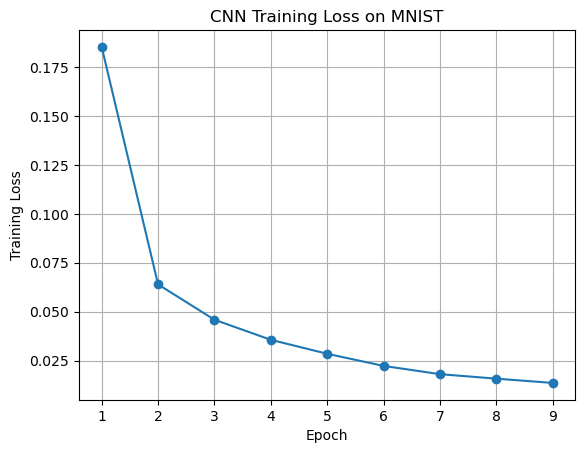

In [7]:
def main():
    compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print_device_info(compute_device)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST(
        root="data",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.MNIST(
        root="data",
        train=False,
        download=True,
        transform=transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=1000,
        shuffle=False
    )

    model = MNISTCnn().to(compute_device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []

    EPOCHS = 9

    for epoch in range(1, EPOCHS + 1):
        print(f"\nEpoch {epoch}/{EPOCHS}")
        
        train_loss = train(model, compute_device, train_loader, optimizer, loss_fn)
        train_losses.append(train_loss)
        
        print(f"Training loss: {train_loss:.4f}")
        
        # Evaluate on test set periodically and at the end
        if epoch % 5 == 0 or epoch == EPOCHS:
            test(model, compute_device, test_loader, loss_fn)

    plot_losses(train_losses)

if __name__ == "__main__":
    main()